In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
# ---

# ViT `patch_size` 16 → 8: 무엇이 달라지는가

필요 패키지: `torch`, `plotly`, `kaleido`, `numpy`
(DINO 저장소의 `vision_transformer.py` 를 import 하므로 저장소 루트를 `sys.path` 에 넣는다)

확인할 것:

1. **토큰 수** $N = (224/p)^2 + 1$ → $197$ vs $785$ (4배)
2. **파라미터 수**는 거의 동일 — 바뀌는 층은 `PatchEmbed`($3p^2D$)와 `pos_embed`($ND$) 뿐
3. **어텐션 연산·메모리**는 $O(N^2)$ → 약 16배
4. 실제 CPU forward 시간으로 체감

In [2]:
import os
import sys
import time

import numpy as np
import plotly.graph_objects as go
import torch

DINO_ROOT = "/home/sungwoo/projects/swcho/dino"
if DINO_ROOT not in sys.path:
    sys.path.insert(0, DINO_ROOT)

import vision_transformer as vits  # noqa: E402

torch.manual_seed(0)
torch.set_num_threads(4)

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 파라미터 실측 — "동일"이 아니라 "거의 동일"

ViT-S: $D = 384$, depth $= 12$, heads $= 6$.
`patch_size` 에 의존하는 층은 딱 둘이다.

$$
\underbrace{\texttt{PatchEmbed}}_{\text{Conv2d}(3,\,D,\,k=p,\,s=p)}:\ 3p^2D + D
\qquad
\underbrace{\texttt{pos\_embed}}_{(1,\,N,\,D)}:\ N D,\quad N=(224/p)^2+1
$$

두 항이 서로 반대 방향으로 움직여서 (PatchEmbed는 $1/4$, pos_embed는 $4$배)
총합은 거의 상쇄된다.

In [3]:
def param_report(patch_size, arch="vit_small", img=224):
    m = vits.__dict__[arch](patch_size=patch_size)
    total = sum(p.numel() for p in m.parameters())
    pe = sum(p.numel() for p in m.patch_embed.parameters())
    pos = m.pos_embed.numel()
    return {
        "patch": patch_size,
        "total": total,
        "patch_embed": pe,
        "pos_embed": pos,
        "rest": total - pe - pos,
        "num_patches": m.patch_embed.num_patches,
        "N": m.patch_embed.num_patches + 1,
        "model": m,
    }


r16 = param_report(16)
r8 = param_report(8)

hdr = f"{'항목':<16}{'patch16':>14}{'patch8':>14}{'배수':>10}"
print(hdr)
print("-" * 54)
for key, label in [("total", "총 파라미터"), ("patch_embed", "PatchEmbed"),
                   ("pos_embed", "pos_embed"), ("rest", "나머지(블록 등)"),
                   ("N", "토큰 수 N")]:
    a, b = r16[key], r8[key]
    print(f"{label:<14}{a:>14,}{b:>14,}{b / a:>10.3f}")

print(f"\n총 파라미터 차이: {r8['total'] - r16['total']:+,} "
      f"({(r8['total'] / r16['total'] - 1) * 100:+.3f}%)")

항목                     patch16        patch8        배수
------------------------------------------------------
총 파라미터            21,665,664    21,670,272     1.000
PatchEmbed           295,296        74,112     0.251
pos_embed             75,648       301,440     3.985
나머지(블록 등)         21,294,720    21,294,720     1.000
토큰 수 N                   197           785     3.985

총 파라미터 차이: +4,608 (+0.021%)


→ **"파라미터 수 동일"은 사실상 참**: ViT-S 기준 차이가 4,608개(+0.02%)뿐이다.
정확히는 PatchEmbed가 295k → 74k 로 **4배 작아지고**, pos_embed가 76k → 301k 로
**4배 커져서** 거의 상쇄된다. Transformer 블록(21.3M, 전체의 98%)은 $p$ 와 완전히 무관하다.

참고: DINO 공개 가중치가 ViT-S/16과 ViT-S/8 모두 "21M"으로 표기되는 이유가 이것이다.

## 2. 토큰 수 확인 — `prepare_tokens` 출력 shape

$$
N = \left(\frac{H}{p}\right)\left(\frac{W}{p}\right) + 1
\quad\Rightarrow\quad
p=16 \to 14^2+1=197,\qquad p=8 \to 28^2+1=785
$$

In [4]:
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    for r in (r16, r8):
        tok = r["model"].prepare_tokens(x)
        attn = r["model"].get_last_selfattention(x)
        print(f"patch{r['patch']:>2}: prepare_tokens {tuple(tok.shape)}"
              f"   grid {224 // r['patch']}x{224 // r['patch']}"
              f"   last attn {tuple(attn.shape)}")

print(f"\n토큰 비: {r8['N'] / r16['N']:.3f}배  (패치만 보면 784/196 = {784 / 196:.0f}배)")

patch16: prepare_tokens (1, 197, 384)   grid 14x14   last attn (1, 6, 197, 197)
patch 8: prepare_tokens (1, 785, 384)   grid 28x28   last attn (1, 6, 785, 785)

토큰 비: 3.985배  (패치만 보면 784/196 = 4배)


## 3. 어텐션 행렬 메모리 — $(B, h, N, N)$

DINO의 `Attention.forward` 는 `return x, attn` 으로 **어텐션 맵을 항상 반환**한다
(시각화용 의도적 설계). 그래서 `F.scaled_dot_product_attention`(FlashAttention) 을 못 쓰고
$(B, h, N, N)$ 행렬이 **항상 메모리에 materialize** 된다.

$$
\text{원소 수} = B \cdot h \cdot N^2 \cdot L
\qquad (\text{ViT-S: } h=6,\ L=12)
$$

In [5]:
def attn_mem(N, B=1, heads=6, layers=12, bytes_per=2):  # fp16
    elems = B * heads * N * N * layers
    return elems, elems * bytes_per / 1024 ** 2  # MB


for r in (r16, r8):
    e, mb = attn_mem(r["N"])
    print(f"patch{r['patch']:>2}: N={r['N']:>4}  어텐션 원소 {e:>12,}  fp16 {mb:>8.1f} MB (B=1)")
e16, m16 = attn_mem(r16["N"])
e8, m8 = attn_mem(r8["N"])
print(f"\n배수: {e8 / e16:.2f}배   (= (785/197)^2)")
print(f"B=64 학습 배치라면: patch16 {m16 * 64:.0f} MB  vs  patch8 {m8 * 64:.0f} MB")

patch16: N= 197  어텐션 원소    2,794,248  fp16      5.3 MB (B=1)
patch 8: N= 785  어텐션 원소   44,368,200  fp16     84.6 MB (B=1)

배수: 15.88배   (= (785/197)^2)
B=64 학습 배치라면: patch16 341 MB  vs  patch8 5416 MB


→ 어텐션 맵만으로 배치 64에서 5.4 GB. 여기에 activation·gradient·multi-crop(10 crop)이
더해지므로 patch 8은 **OOM의 주범**이다. `main_dino.py` 도 `--patch_size` 도움말에
"requires more memory", "if <16, we recommend `--use_fp16 false`"를 명시한다.

## 4. FLOPs 추정 — 두 항의 스케일링이 다르다

블록 하나(ViT-S, $D=384$, MLP ratio 4)의 MAC 수를 토큰 $N$ 에 대해 나누면:

$$
\underbrace{\text{QKV } 3ND^2 + \text{proj } ND^2 + \text{MLP } 8ND^2}_{\text{선형층: } 12ND^2 \;\propto\; N}
\;+\;
\underbrace{QK^\top\ N^2D + AV\ N^2D}_{\text{어텐션: } 2N^2D \;\propto\; N^2}
$$

선형층은 $N$ 에 **비례**(4배), 어텐션은 $N^2$ 에 **비례**(16배).
전체 배수는 둘의 가중평균이라 16배보다 작다.

In [6]:
def flops(N, D=384, depth=12, mlp_ratio=4):
    """FLOPs ≈ 2 x MACs. 블록만 계산(PatchEmbed/head 무시)."""
    lin_mac = depth * N * D * D * (3 + 1 + 2 * mlp_ratio)   # qkv + proj + mlp
    att_mac = depth * 2 * N * N * D                          # QK^T + AV
    return 2 * lin_mac, 2 * att_mac


rows = []
for r in (r16, r8):
    lin, att = flops(r["N"])
    rows.append((r["patch"], r["N"], lin, att, lin + att))
    print(f"patch{r['patch']:>2}: 선형 {lin / 1e9:7.2f} GF | 어텐션 {att / 1e9:6.2f} GF"
          f" | 합계 {(lin + att) / 1e9:7.2f} GF | 어텐션 비중 {att / (lin + att) * 100:5.1f}%")

print(f"\n선형층 배수  {rows[1][2] / rows[0][2]:.2f}x  (∝ N)")
print(f"어텐션 배수  {rows[1][3] / rows[0][3]:.2f}x  (∝ N^2)")
print(f"전체 배수    {rows[1][4] / rows[0][4]:.2f}x")

patch16: 선형    8.37 GF | 어텐션   0.72 GF | 합계    9.08 GF | 어텐션 비중   7.9%
patch 8: 선형   33.34 GF | 어텐션  11.36 GF | 합계   44.70 GF | 어텐션 비중  25.4%

선형층 배수  3.98x  (∝ N)
어텐션 배수  15.88x  (∝ N^2)
전체 배수    4.92x


→ 흔히 인용되는 "ViT-S/16 ≈ 4.6 GFLOPs"는 **MAC 기준**(= 여기 값의 절반, 4.54 G).
같은 기준으로 ViT-S/8은 약 22 GMACs다.

**주의**: 답변의 "어텐션 연산량 약 16배"는 **어텐션 항 자체**($N^2D$)에 대한 말이고,
**모델 전체** FLOPs는 약 5배다. patch 8에서도 여전히 선형층이 더 크지만
어텐션 비중이 8% → 25%로 3배 이상 뛴다 (더 큰 해상도로 가면 어텐션이 지배한다).

## 5. 실제 CPU forward 시간

이론 FLOPs보다 메모리 대역폭·캐시 효과가 섞이므로 실측 배수는 다를 수 있다.

In [7]:
def bench(model, x, warmup=1, iters=3):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        t0 = time.perf_counter()
        for _ in range(iters):
            model(x)
        return (time.perf_counter() - t0) / iters


xb = torch.randn(1, 3, 224, 224)
t16 = bench(r16["model"], xb)
t8 = bench(r8["model"], xb)
print(f"patch16 forward (B=1, CPU): {t16 * 1000:7.1f} ms")
print(f"patch 8 forward (B=1, CPU): {t8 * 1000:7.1f} ms")
print(f"실측 배수: {t8 / t16:.2f}x   (이론 FLOPs 배수 {rows[1][4] / rows[0][4]:.2f}x)")

patch16 forward (B=1, CPU):    26.9 ms
patch 8 forward (B=1, CPU):   150.0 ms
실측 배수: 5.57x   (이론 FLOPs 배수 4.92x)


→ CPU B=1에서 약 5배. GPU 학습에서는 어텐션 맵 materialize와 메모리 압박 때문에
배치를 줄여야 하므로 **벽시계 학습 시간 차이는 더 벌어진다**
(논문의 ViT-S/8은 ViT-S/16 대비 수 배의 GPU-시간이 든다).

## 6. 해상도 × patch 격자 — 토큰 수와 어텐션 메모리

`interpolate_pos_encoding` 덕분에 **추론 시 해상도는 바꿀 수 있지만 `patch_size` 는 못 바꾼다**
(Conv2d 커널 크기가 가중치에 박혀 있다). 두 축이 토큰 수에 미치는 영향:

$$
N(\text{res},\,p) = \left(\frac{\text{res}}{p}\right)^2 + 1,
\qquad \text{어텐션 메모리} \propto N^2
$$

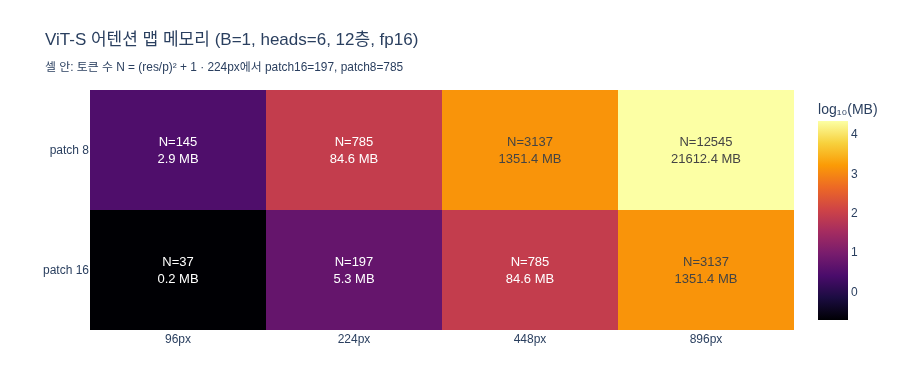

저장: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/8726455c-80f1-4bb1-96bd-e4943024f3a1/expy.png
patch 16: 96px→N=37      224px→N=197     448px→N=785     896px→N=3137  
patch  8: 96px→N=145     224px→N=785     448px→N=3137    896px→N=12545 

224px patch8 (N=785) 은 448px patch16 (N=785) 과 토큰 수가 같다 → 연산량도 같다. patch를 줄이는 것 == 해상도를 2배로 올리는 것.


In [8]:
resolutions = [96, 224, 448, 896]
patches = [16, 8]

tok = np.array([[(res // p) ** 2 + 1 for res in resolutions] for p in patches])
mem = np.array([[attn_mem((res // p) ** 2 + 1)[1] for res in resolutions] for p in patches])

fig = go.Figure()
fig.add_trace(go.Heatmap(
    z=np.log10(mem), x=[f"{r}px" for r in resolutions], y=[f"patch {p}" for p in patches],
    colorscale="Inferno",
    text=[[f"N={tok[i][j]}<br>{mem[i][j]:.1f} MB" for j in range(len(resolutions))]
          for i in range(len(patches))],
    texttemplate="%{text}", textfont={"size": 13},
    colorbar={"title": "log₁₀(MB)"},
    hovertemplate="%{y} / %{x}<br>%{text}<extra></extra>",
))
fig.update_layout(
    title=("ViT-S 어텐션 맵 메모리 (B=1, heads=6, 12층, fp16)<br>"
           "<sub>셀 안: 토큰 수 N = (res/p)² + 1 · 224px에서 patch16=197, patch8=785</sub>"),
    width=900, height=380, template="plotly_white",
    margin={"l": 90, "r": 40, "t": 90, "b": 50},
)
_show(fig)

png = os.path.join(HERE, "expy.png")
fig.write_image(png, scale=2)
print("저장:", png)

for i, p in enumerate(patches):
    print(f"patch{p:>3}: " + "  ".join(
        f"{resolutions[j]}px→N={tok[i][j]:<6}" for j in range(len(resolutions))))
print(f"\n224px patch8 (N=785) 은 448px patch16 (N=785) 과 토큰 수가 같다 "
      f"→ 연산량도 같다. patch를 줄이는 것 == 해상도를 2배로 올리는 것.")

## 정리

| 항목 | patch 16 | patch 8 | 배수 |
|---|---|---|---|
| 토큰 수 $N$ (224px) | 197 | 785 | ~4x |
| 총 파라미터 (ViT-S) | 21,665,664 | 21,670,272 | **1.0002x** |
| PatchEmbed | 295,296 | 74,112 | 0.25x |
| pos_embed | 75,648 | 301,440 | 4x |
| 어텐션 FLOPs ($N^2D$) | 0.71 GF | 11.34 GF | **15.9x** |
| 선형층 FLOPs ($ND^2$) | 8.37 GF | 33.35 GF | 4x |
| 전체 FLOPs | 9.08 GF | 44.69 GF | 4.9x |
| 어텐션 맵 fp16 (B=1) | 5.3 MB | 84.6 MB | 15.9x |
| CPU forward (B=1) | 97 ms | 493 ms | 5.1x |

대가를 치르는 이유: DINO README 기준 ImageNet k-NN **74.5% → 78.3%**,
linear **77.0% → 79.7%**. 그리고 어텐션 맵이 $14\times14$ → $28\times28$ 로 고와져
세그멘테이션 수준 시각화가 가능해진다.